# Testing qipQST

## Imports

In [2]:
import numpy as np

import h5py

import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use('dark_background')
plt.style.use('default')

## Ramsey Plot

In [ ]:
f = h5py.File("ramsey_results.h5")
results = f["results"]
parameters = f["parameters"]

assert(isinstance(results, h5py.Group))
assert(isinstance(parameters, h5py.Group))

guess_larmors = parameters["qubits_larmor_base_value"]
taus = parameters["circuit_Idle_duration"]
results = results["probabilities"]

In [ ]:
assert(isinstance(results, h5py.Dataset))
assert(isinstance(guess_larmors, h5py.Dataset))
assert(isinstance(taus, h5py.Dataset))

X, Y = np.meshgrid(guess_larmors, taus)
pcolorm = plt.pcolormesh(X, Y, results, shading="nearest", cmap="magma")
# pcolorm = plt.pcolormesh(X, Y, results, shading="gouraud", cmap="magma")
plt.colorbar(pcolorm)
plt.ylabel("Tau")
plt.xlabel("Guess")
plt.title("")
plt.show()

tau_index = 50
plt.plot(guess_larmors[:], results[tau_index])
plt.title("Slide at $\\tau = {}$".format(taus[tau_index]))
plt.ylabel("Probability")
plt.xlabel("Guess")
plt.show()

In [ ]:
f.close()

## ATM Plot

In [30]:
f = h5py.File("atm_results.h5")
results = f["results"]
parameters = f["parameters"]

In [31]:
assert(isinstance(results, h5py.Group))
assert(isinstance(parameters, h5py.Group))
probabilities = results["probabilities"]
detunings = parameters["qubits_larmor_base_value"]

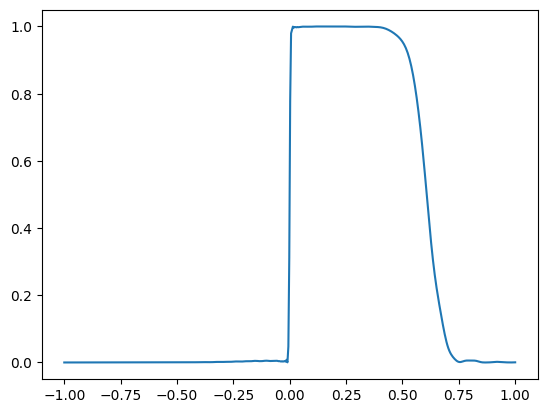

In [32]:
assert(isinstance(probabilities, h5py.Dataset))
assert(isinstance(detunings, h5py.Dataset))

plt.plot(detunings[:], probabilities[:])
plt.show()

In [33]:
# f.close()
# f = h5py.File("circuit_data.h5")
# print(f.keys())
# times = f["time_data"]
# frequencies = f["frequency_data"]
# amplitudes = f["amplitude_data"]
# pulseData = f["pulse_data"]

In [34]:
# assert(isinstance(times, h5py.Dataset))
# assert(isinstance(frequencies, h5py.Dataset))
# assert(isinstance(amplitudes, h5py.Dataset))
# assert(isinstance(pulseData, h5py.Dataset))

# plt.plot(times[:], frequencies[:])
# plt.show()

# plt.plot(times[:], amplitudes[:])
# plt.show()

# plt.plot(times[:], pulseData[:])
# plt.show()


In [38]:
f.close()

## ATM Bloch

In [36]:
f = h5py.File("atm_results.h5")
results = f["results"]
parameters = f["parameters"]

In [37]:
assert(isinstance(results, h5py.Group))

bloch_coords = results["bloch_coords"]
assert(isinstance(bloch_coords, h5py.Group))

x_coords = bloch_coords["x_coords"]
y_coords = bloch_coords["y_coords"]
z_coords = bloch_coords["z_coords"]

KeyError: "Unable to synchronously open object (object 'bloch_coords' doesn't exist)"

In [ ]:
assert(isinstance(x_coords, h5py.Dataset))
assert(isinstance(y_coords, h5py.Dataset))
assert(isinstance(z_coords, h5py.Dataset))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.invert_yaxis()
ax.set_axis_off()

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot a basic wireframe.
ax.plot_wireframe(x, y, z, rstride=10, cstride=10, color='grey', alpha = 0.15)

# Plot the surface
ax.plot_surface(x, y, z, alpha=0.05, color = 'grey')

# Prepare arrays x, y, z
wireAngles = np.linspace(0, 2 * np.pi, 100)

x = np.cos(wireAngles)
y = np.sin(wireAngles)
z = np.zeros(np.shape(x))
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)

x = np.cos(wireAngles)
y = np.zeros(np.shape(x))
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.3)

x = np.zeros(np.shape(y))
y = np.cos(wireAngles)
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)


ax.plot([-1, 1], [0, 0], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [-1, 1], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [0, 0], [-1, 1], color = 'dimgray', alpha = 0.4)

ax.text(0, 0, 1.1, "$|+z\\rangle$")
ax.text(0, 1.1, 0, "$|+y\\rangle$")
ax.text(1.1, 0, 0, "$|+x\\rangle$")

# ax.plot(x, y, z)
    
for i in range(len(x_coords) - 1):
    ax.plot(x_coords[i:i+2], y_coords[i:i+2], z_coords[i:i+2], color=mpl.colormaps['jet'](i/len(x_coords)))


# Set an equal aspect ratio
ax.set_aspect('equal')

plt.show()

In [ ]:
f.close()

## Larmor Plot

In [ ]:
f = h5py.File("larmor_data.h5")
larmor_values = f["larmor_data"]
time_values = f["time_data"]

In [ ]:
assert(isinstance(larmor_values, h5py.Dataset))
assert(isinstance(time_values, h5py.Dataset))

fig, ax = plt.subplots(figsize = (20, 5))
ax.plot(time_values[:], larmor_values[:])
plt.show()

In [ ]:
f.close()

## Rabi Plot

In [99]:
f = h5py.File("rabi_results.h5")
results = f["results"]
parameters = f["parameters"]

In [100]:
assert(isinstance(results, h5py.Group))

bloch_coords = results["bloch_coords"]
assert(isinstance(bloch_coords, h5py.Group))

x_coords = bloch_coords["x_coords"]
y_coords = bloch_coords["y_coords"]
z_coords = bloch_coords["z_coords"]

probabilities = results["probabilities"]

assert(isinstance(probabilities, h5py.Dataset))
durations = np.linspace(0, 10, len(probabilities))

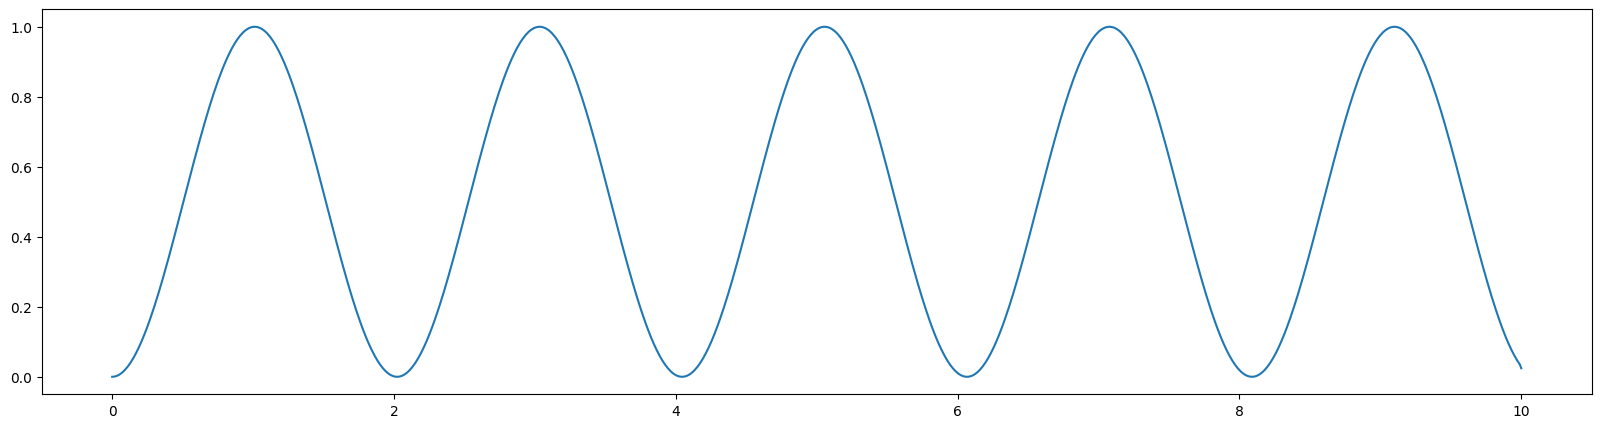

In [101]:
assert(isinstance(probabilities, h5py.Dataset))

fig, ax = plt.subplots(figsize = (20, 5))
ax.plot(durations[:], probabilities[:])
plt.show()

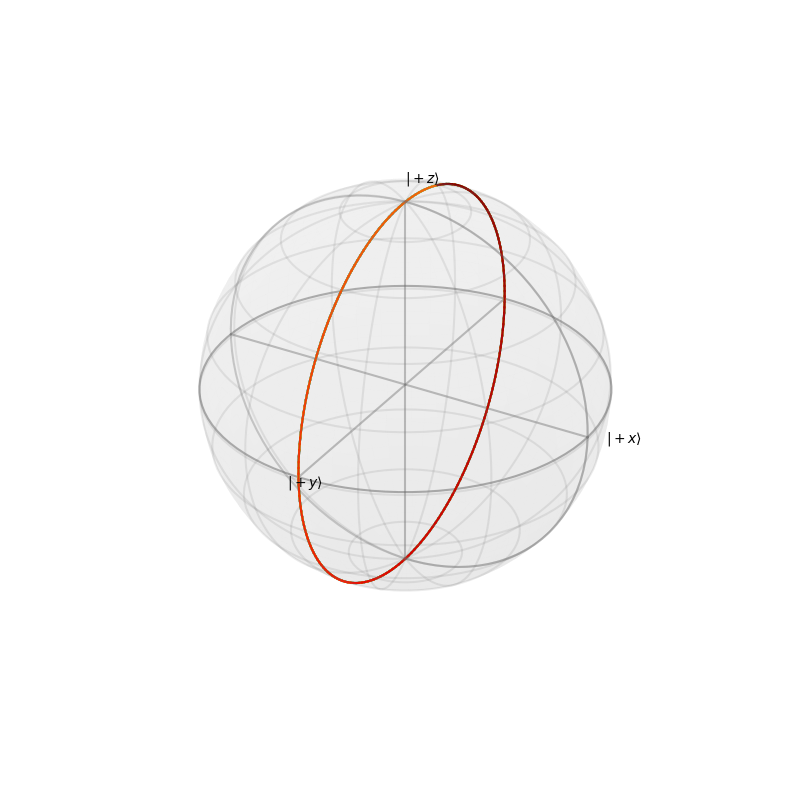

In [102]:
assert(isinstance(x_coords, h5py.Dataset))
assert(isinstance(y_coords, h5py.Dataset))
assert(isinstance(z_coords, h5py.Dataset))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.invert_yaxis()
ax.set_axis_off()

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot a basic wireframe.
ax.plot_wireframe(x, y, z, rstride=10, cstride=10, color='grey', alpha = 0.15)

# Plot the surface
ax.plot_surface(x, y, z, alpha=0.05, color = 'grey')

# Prepare arrays x, y, z
wireAngles = np.linspace(0, 2 * np.pi, 100)

x = np.cos(wireAngles)
y = np.sin(wireAngles)
z = np.zeros(np.shape(x))
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)

x = np.cos(wireAngles)
y = np.zeros(np.shape(x))
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.3)

x = np.zeros(np.shape(y))
y = np.cos(wireAngles)
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)


ax.plot([-1, 1], [0, 0], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [-1, 1], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [0, 0], [-1, 1], color = 'dimgray', alpha = 0.4)

ax.text(0, 0, 1.1, "$|+z\\rangle$")
ax.text(0, 1.1, 0, "$|+y\\rangle$")
ax.text(1.1, 0, 0, "$|+x\\rangle$")

# ax.plot(x, y, z)

for i in range(len(x_coords) - 1):
    ax.plot(x_coords[i:i+2], y_coords[i:i+2], z_coords[i:i+2], color=mpl.colormaps['jet'](i/len(x_coords)))


# Set an equal aspect ratio
ax.set_aspect('equal')

plt.show()

In [103]:
f.close()

## Hahn Plot

In [ ]:
f = h5py.File("hahn_results.h5")
results = f["results"]
parameters = f["parameters"]

In [ ]:
assert(isinstance(results, h5py.Group))
assert(isinstance(parameters, h5py.Group))

probabilities = results["probabilities"]
taus = parameters["circuit_Idle_duration"]

In [ ]:
assert(isinstance(probabilities, h5py.Dataset))
assert(isinstance(taus, h5py.Dataset))

fig, ax = plt.subplots(figsize = (6, 6))
ax.plot(taus[:], probabilities[:])
ax.set_ylabel("Probability")
ax.set_xlabel("Tau")
ax.set_ylim(0, 1)
plt.show()

In [ ]:
f.close()

## T2 Plot

In [ ]:
f = h5py.File("T2_relaxation.h5")
results = f["results"]
parameters = f["parameters"]

In [ ]:
assert(isinstance(results, h5py.Group))
assert(isinstance(parameters, h5py.Group))
probabilities = results["probabilities"]
taus = parameters["circuit_Idle_duration"]

In [ ]:
assert(isinstance(probabilities, h5py.Dataset))
assert(isinstance(taus, h5py.Dataset))

fig, ax = plt.subplots(figsize = (6, 6))
ax.plot(taus[:], probabilities[:])
ax.set_ylabel("Probability")
ax.set_xlabel("Tau")
ax.set_ylim(0, 1)
plt.show()

In [ ]:
f.close()

## Test Plot

In [ ]:
f = h5py.File("test_results.h5")
results = f["results"]
parameters = f["parameters"]

In [ ]:
assert(isinstance(results, h5py.Group))

bloch_coords = results["bloch_coords"]
assert(isinstance(bloch_coords, h5py.Group))

x_coords = bloch_coords["x_coords"]
y_coords = bloch_coords["y_coords"]
z_coords = bloch_coords["z_coords"]

probabilities = results["probabilities"]

assert(isinstance(x_coords, h5py.Dataset))
assert(isinstance(y_coords, h5py.Dataset))
assert(isinstance(z_coords, h5py.Dataset))
print(x_coords.len())
print(y_coords.len())
print(z_coords.len())

In [ ]:
assert(isinstance(x_coords, h5py.Dataset))
assert(isinstance(y_coords, h5py.Dataset))
assert(isinstance(z_coords, h5py.Dataset))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.invert_yaxis()
ax.set_axis_off()

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot a basic wireframe.
ax.plot_wireframe(x, y, z, rstride=10, cstride=10, color='grey', alpha = 0.15)

# Plot the surface
ax.plot_surface(x, y, z, alpha=0.05, color = 'grey')

# Prepare arrays x, y, z
wireAngles = np.linspace(0, 2 * np.pi, 100)

x = np.cos(wireAngles)
y = np.sin(wireAngles)
z = np.zeros(np.shape(x))
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)

x = np.cos(wireAngles)
y = np.zeros(np.shape(x))
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.3)

x = np.zeros(np.shape(y))
y = np.cos(wireAngles)
z = np.sin(wireAngles)
ax.plot(x, y, z, color = 'dimgray', alpha = 0.5)


ax.plot([-1, 1], [0, 0], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [-1, 1], [0, 0], color = 'dimgray', alpha = 0.4)
ax.plot([0, 0], [0, 0], [-1, 1], color = 'dimgray', alpha = 0.4)

ax.text(0, 0, 1.1, "$|+z\\rangle$")
ax.text(0, 1.1, 0, "$|+y\\rangle$")
ax.text(1.1, 0, 0, "$|+x\\rangle$")

# ax.plot(x, y, z)
    
for i in range(len(x_coords) - 1):
    ax.plot(x_coords[i:i+2], y_coords[i:i+2], z_coords[i:i+2], color=mpl.colormaps['jet'](i/len(x_coords)))


# Set an equal aspect ratio
ax.set_aspect('equal')

plt.show()

In [ ]:
f.close()